Analysis code for

# Personality Change After Traumatic Brain Injury: A Systematic Review and Meta-analysis

In [32]:
# Load the libraries
library(dplyr)
library(readxl)
library(meta)
library(dmetar)
library(ggplot2)
library(metafor)

# Note: the dmetar package is not available on CRAN.
# Install instructions from github here: https://dmetar.protectlab.org/

Load data file

In [2]:
# Define the data directory path
data_dir <- "/home/main/Dropbox/Studies/LaurenPersonalitySysReview/Analysis/"
output_dir <- "/home/main/Dropbox/Studies/LaurenPersonalitySysReview/Analysis/"

# Load the data into main_df
main_df <- read_excel(paste(data_dir, "Prev_DataExtraction.xlsx", sep = ""), sheet = "Sheet1")

# Copy main_df to pc_df
pc_df <- main_df

Data cleaning and variable typing

In [3]:
# Change key variables to numeric
pc_df$TBI_N <- as.numeric(pc_df$TBI_N)
pc_df$PersChange_N <- as.numeric(pc_df$PersChange_N)

# Prepare labels for the left column
pc_df$Authors <- paste(pc_df$Authors, " (", pc_df$Year, ")", sep = "")

Run main meta-analysis

In [4]:
pc_meta <- metaprop(PersChange_N, TBI_N,
                      studlab = Authors,
                      sm = "PFT",
                      method.tau = "PM",
                      method.ci = "NAsm",
                      data = pc_df)

Text summary of meta-analysis

In [5]:
summary(pc_meta)

                        proportion           95%-CI %W(common) %W(random)
Aldossary et al (2019)      0.2231 [0.1736; 0.2768]       10.7        6.3
Balan et al (2021)          0.3659 [0.2240; 0.5201]        1.8        5.8
Diaz et al (2014)           0.3415 [0.2029; 0.4946]        1.8        5.8
Koponen et al (2002)        0.2333 [0.1339; 0.3496]        2.6        6.0
Diaz et al (2012)           0.3333 [0.1810; 0.5046]        1.4        5.7
Franulic et al (2000)       0.3214 [0.1591; 0.5077]        1.2        5.6
Thomsen (1984)              0.7917 [0.6030; 0.9346]        1.0        5.5
Weddell et al (1980)        0.7045 [0.5601; 0.8314]        1.9        5.9
Hibbard et al (2000)        0.1735 [0.1394; 0.2105]       18.7        6.4
Weddell Wood (2016)         0.6761 [0.5621; 0.7806]        3.0        6.1
Weddell Leggett (2006)      0.6207 [0.5159; 0.7202]        3.7        6.1
Li et al (2022)             0.3311 [0.3026; 0.3602]       43.8        6.4
Rao et al (2008)            0.3148 [0.

Forest plot

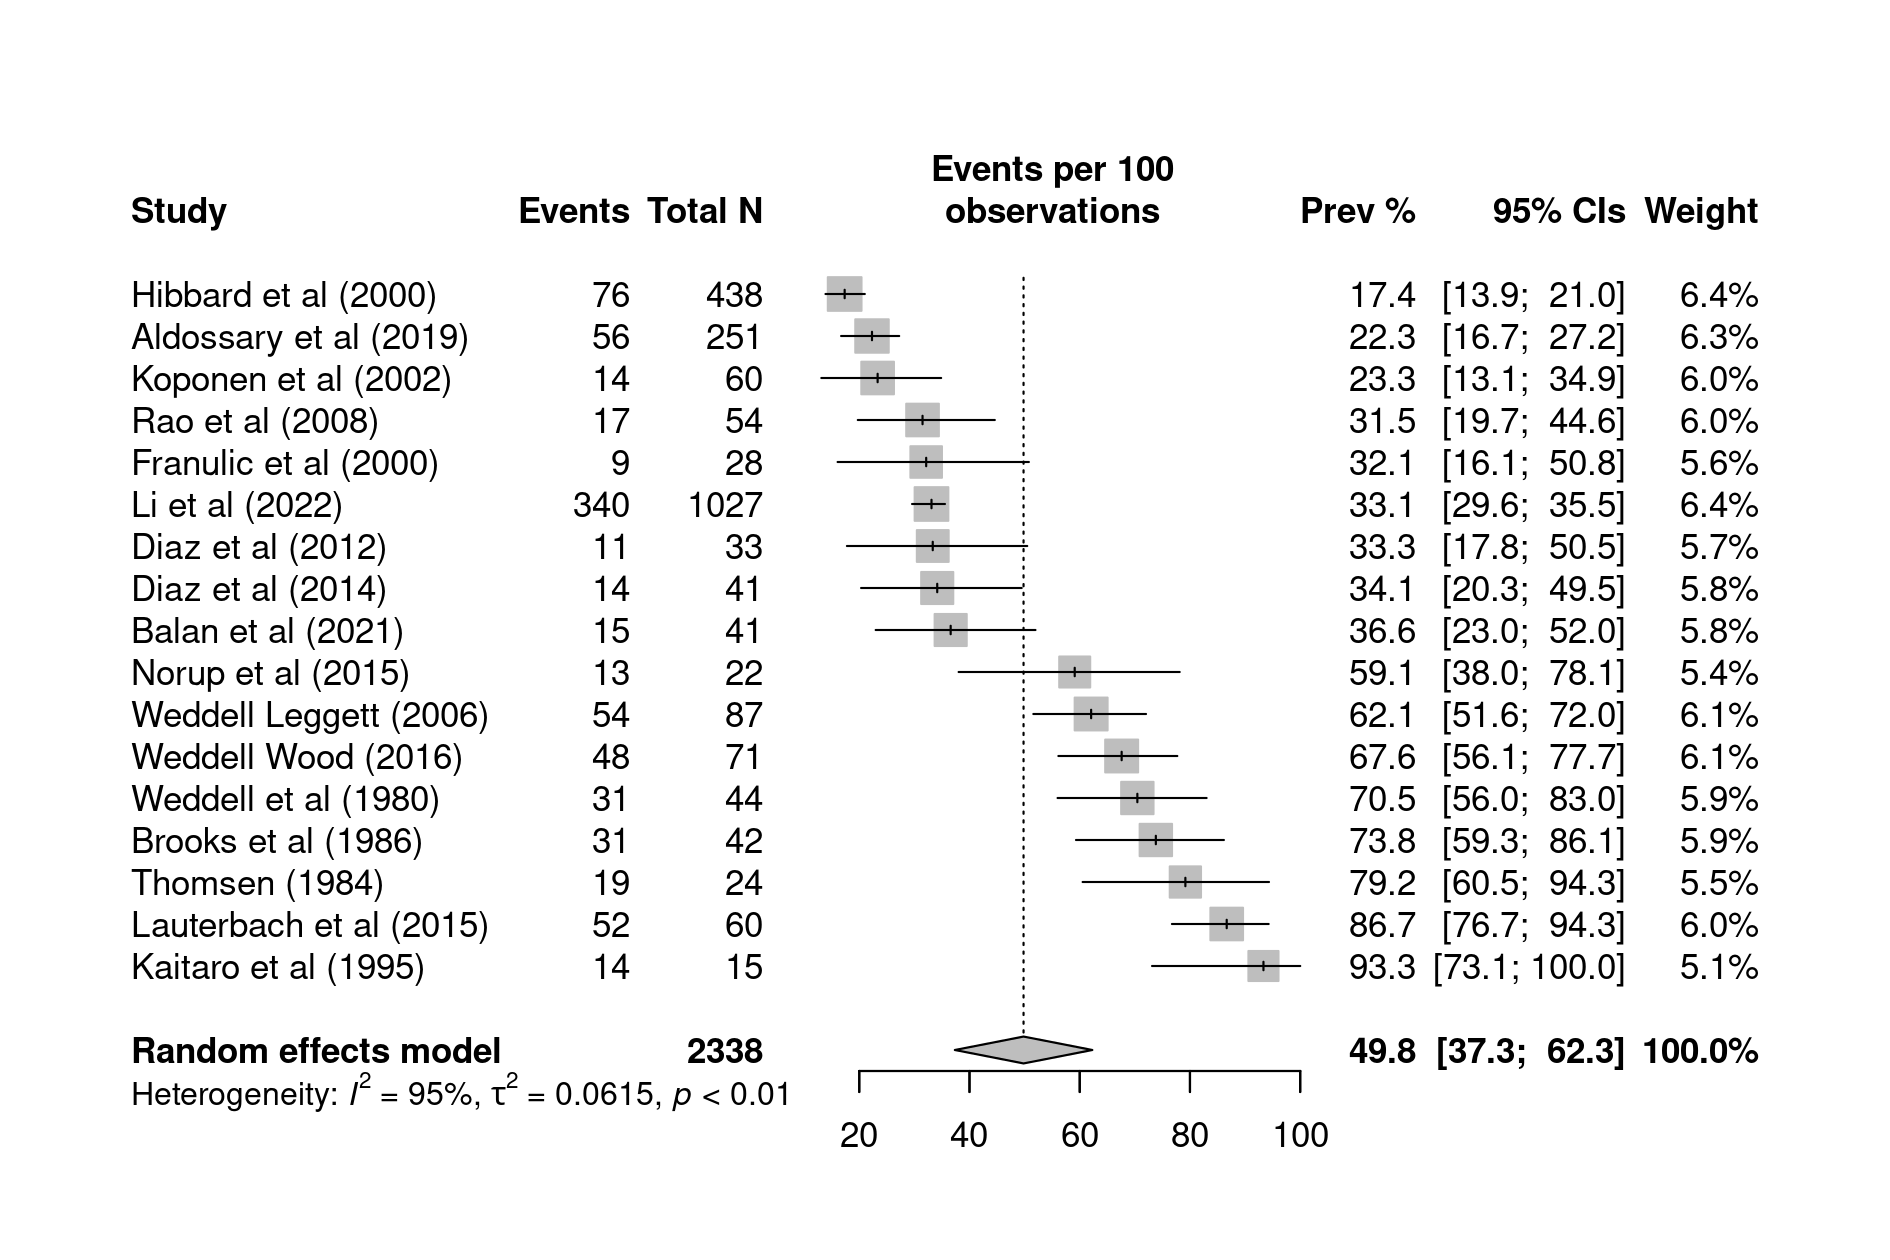

In [6]:
# Set image size
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 210)

# Forest plot
forest(pc_meta,
       studlab = Authors,
       common = FALSE,
       test.effect.common = FALSE,
       test.overall.common = FALSE,
       leftlabs = c("Study", "Events", "Total N"),
       rightlabs = c("Prev %", "95% CIs", "Weight"),
       rightcols = c("effect", "ci", "w.random"),
       digits = 1,
       pscale = 100,
       xlim = c(10, 100),
       colgap.forest.left = unit(5, "mm"),
       colgap.forest.right = unit(0, "mm"),
       sortvar = TE
)

### Subgroup analyses

Study design

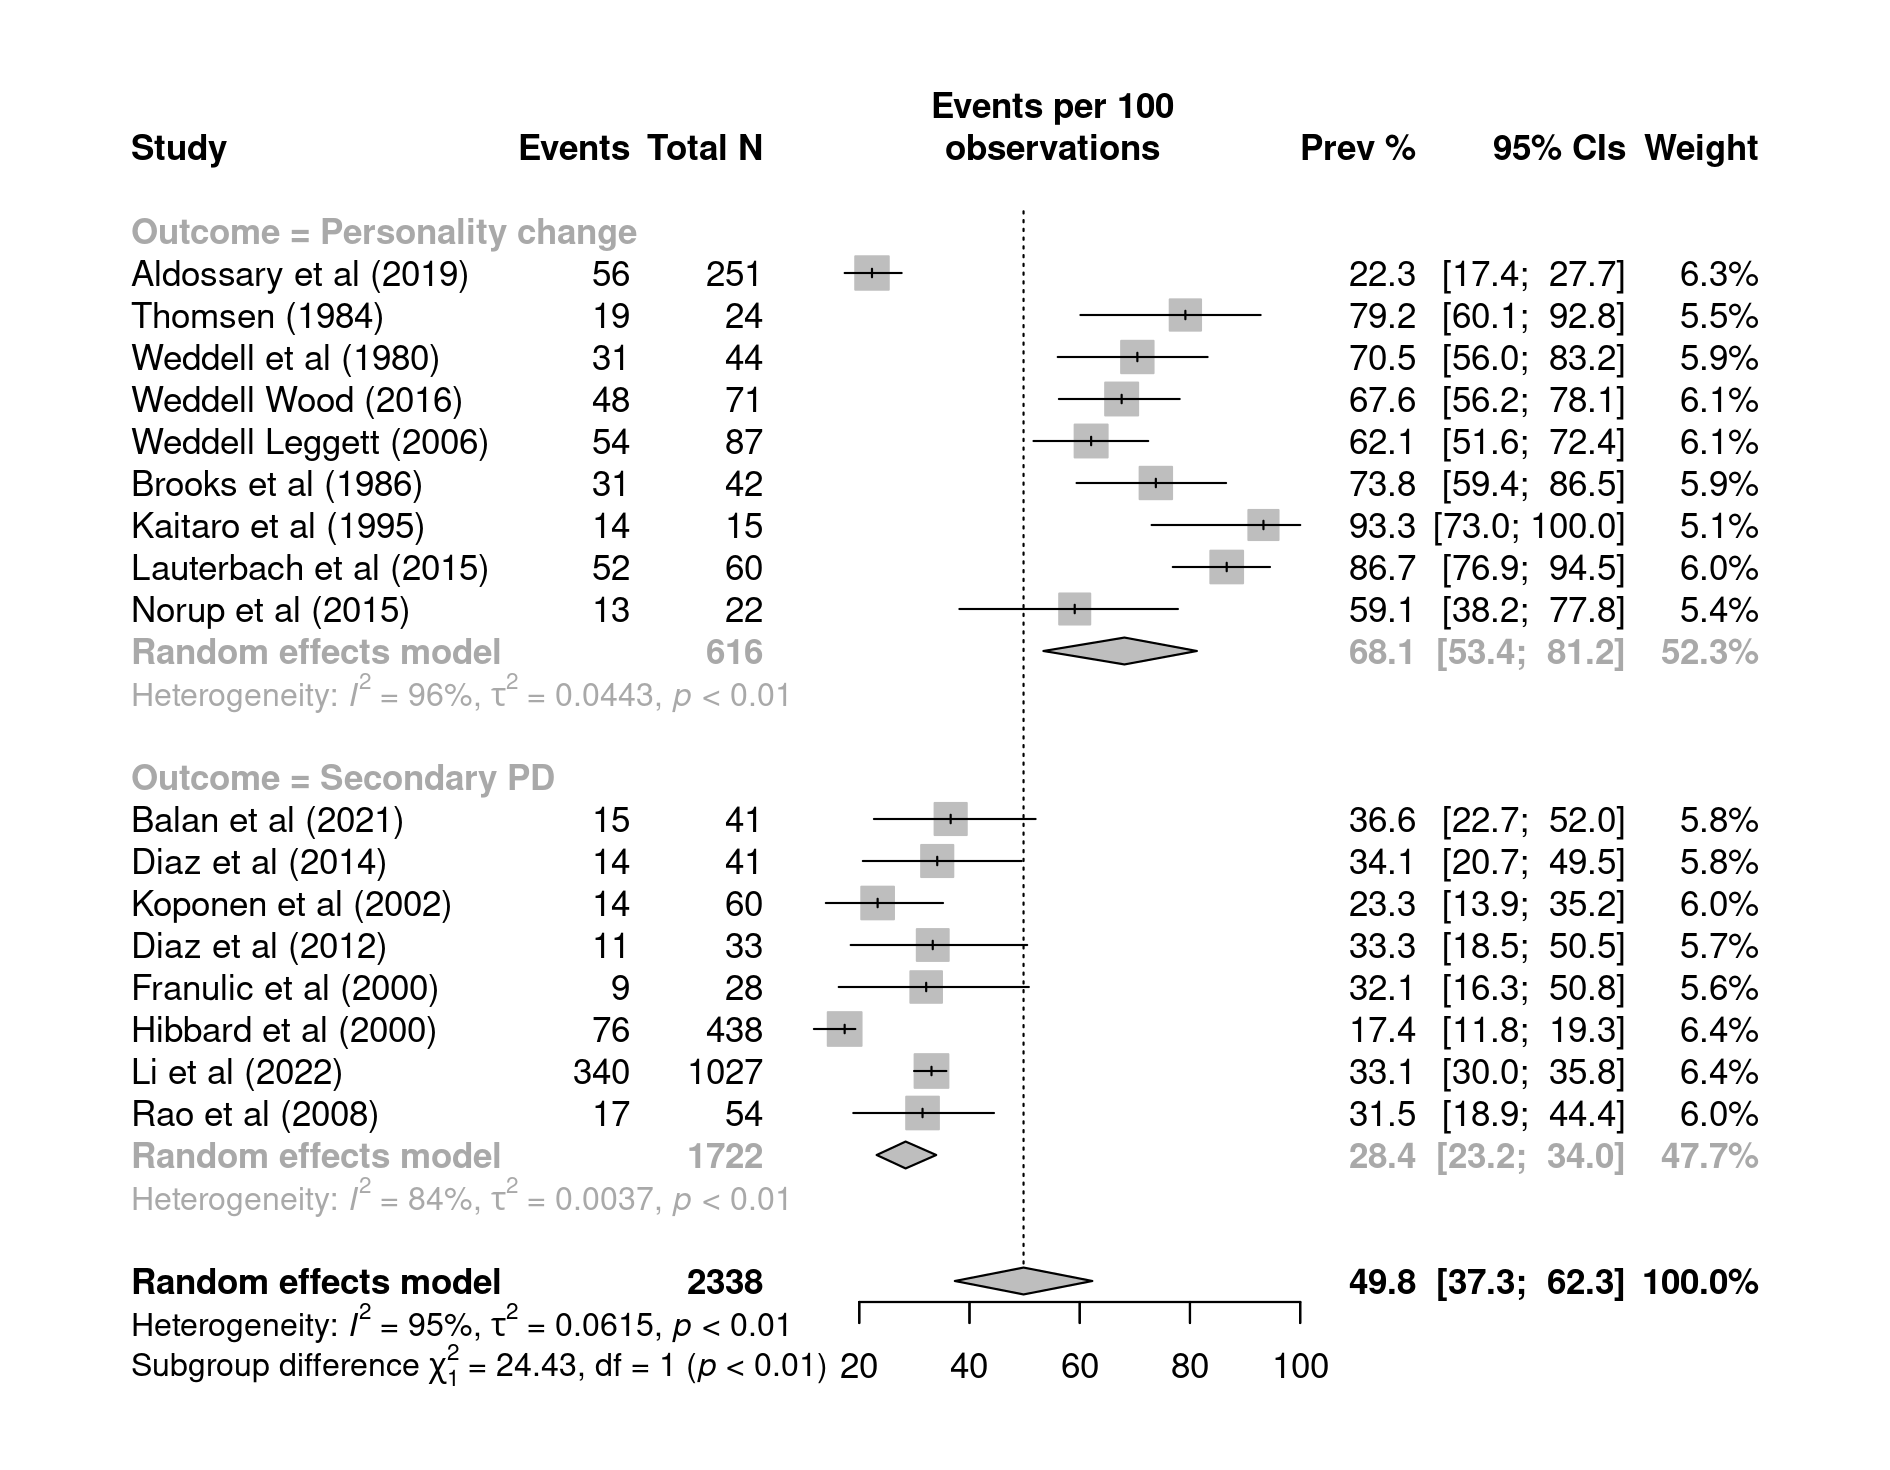

In [7]:
# Meta-analysis with subgroup by outcome type 
pc_outcome_meta <- metaprop(PersChange_N, TBI_N,
                            studlab = Authors,
                            subgroup = MetricType,
                            sm = "PFT",
                            method.tau = "PM",
                            method.ci = "NAsm",
                            data = pc_df)


# Set image size
options(repr.plot.width = 9, repr.plot.height = 7, repr.plot.res = 210)

# Forest plot
forest(pc_outcome_meta,
       subgroup.name = "Outcome",
       common = FALSE,
       common.subgroup = FALSE,
       test.effect.common = FALSE,
       test.overall.common = FALSE,
       test.effect.subgroup.common = FALSE,
       test.subgroup.common = FALSE,
       label.test.subgroup.random = "Subgroup difference ",
       leftlabs = c("Study", "Events", "Total N"),
       rightlabs = c("Prev %", "95% CIs", "Weight"),
       rightcols = c("effect", "ci", "w.random"),
       digits = 1,
       pscale = 100,
       xlim = c(10, 100),
       colgap.forest.left = unit(5, "mm"),
       colgap.forest.right = unit(0, "mm")
)

Study design

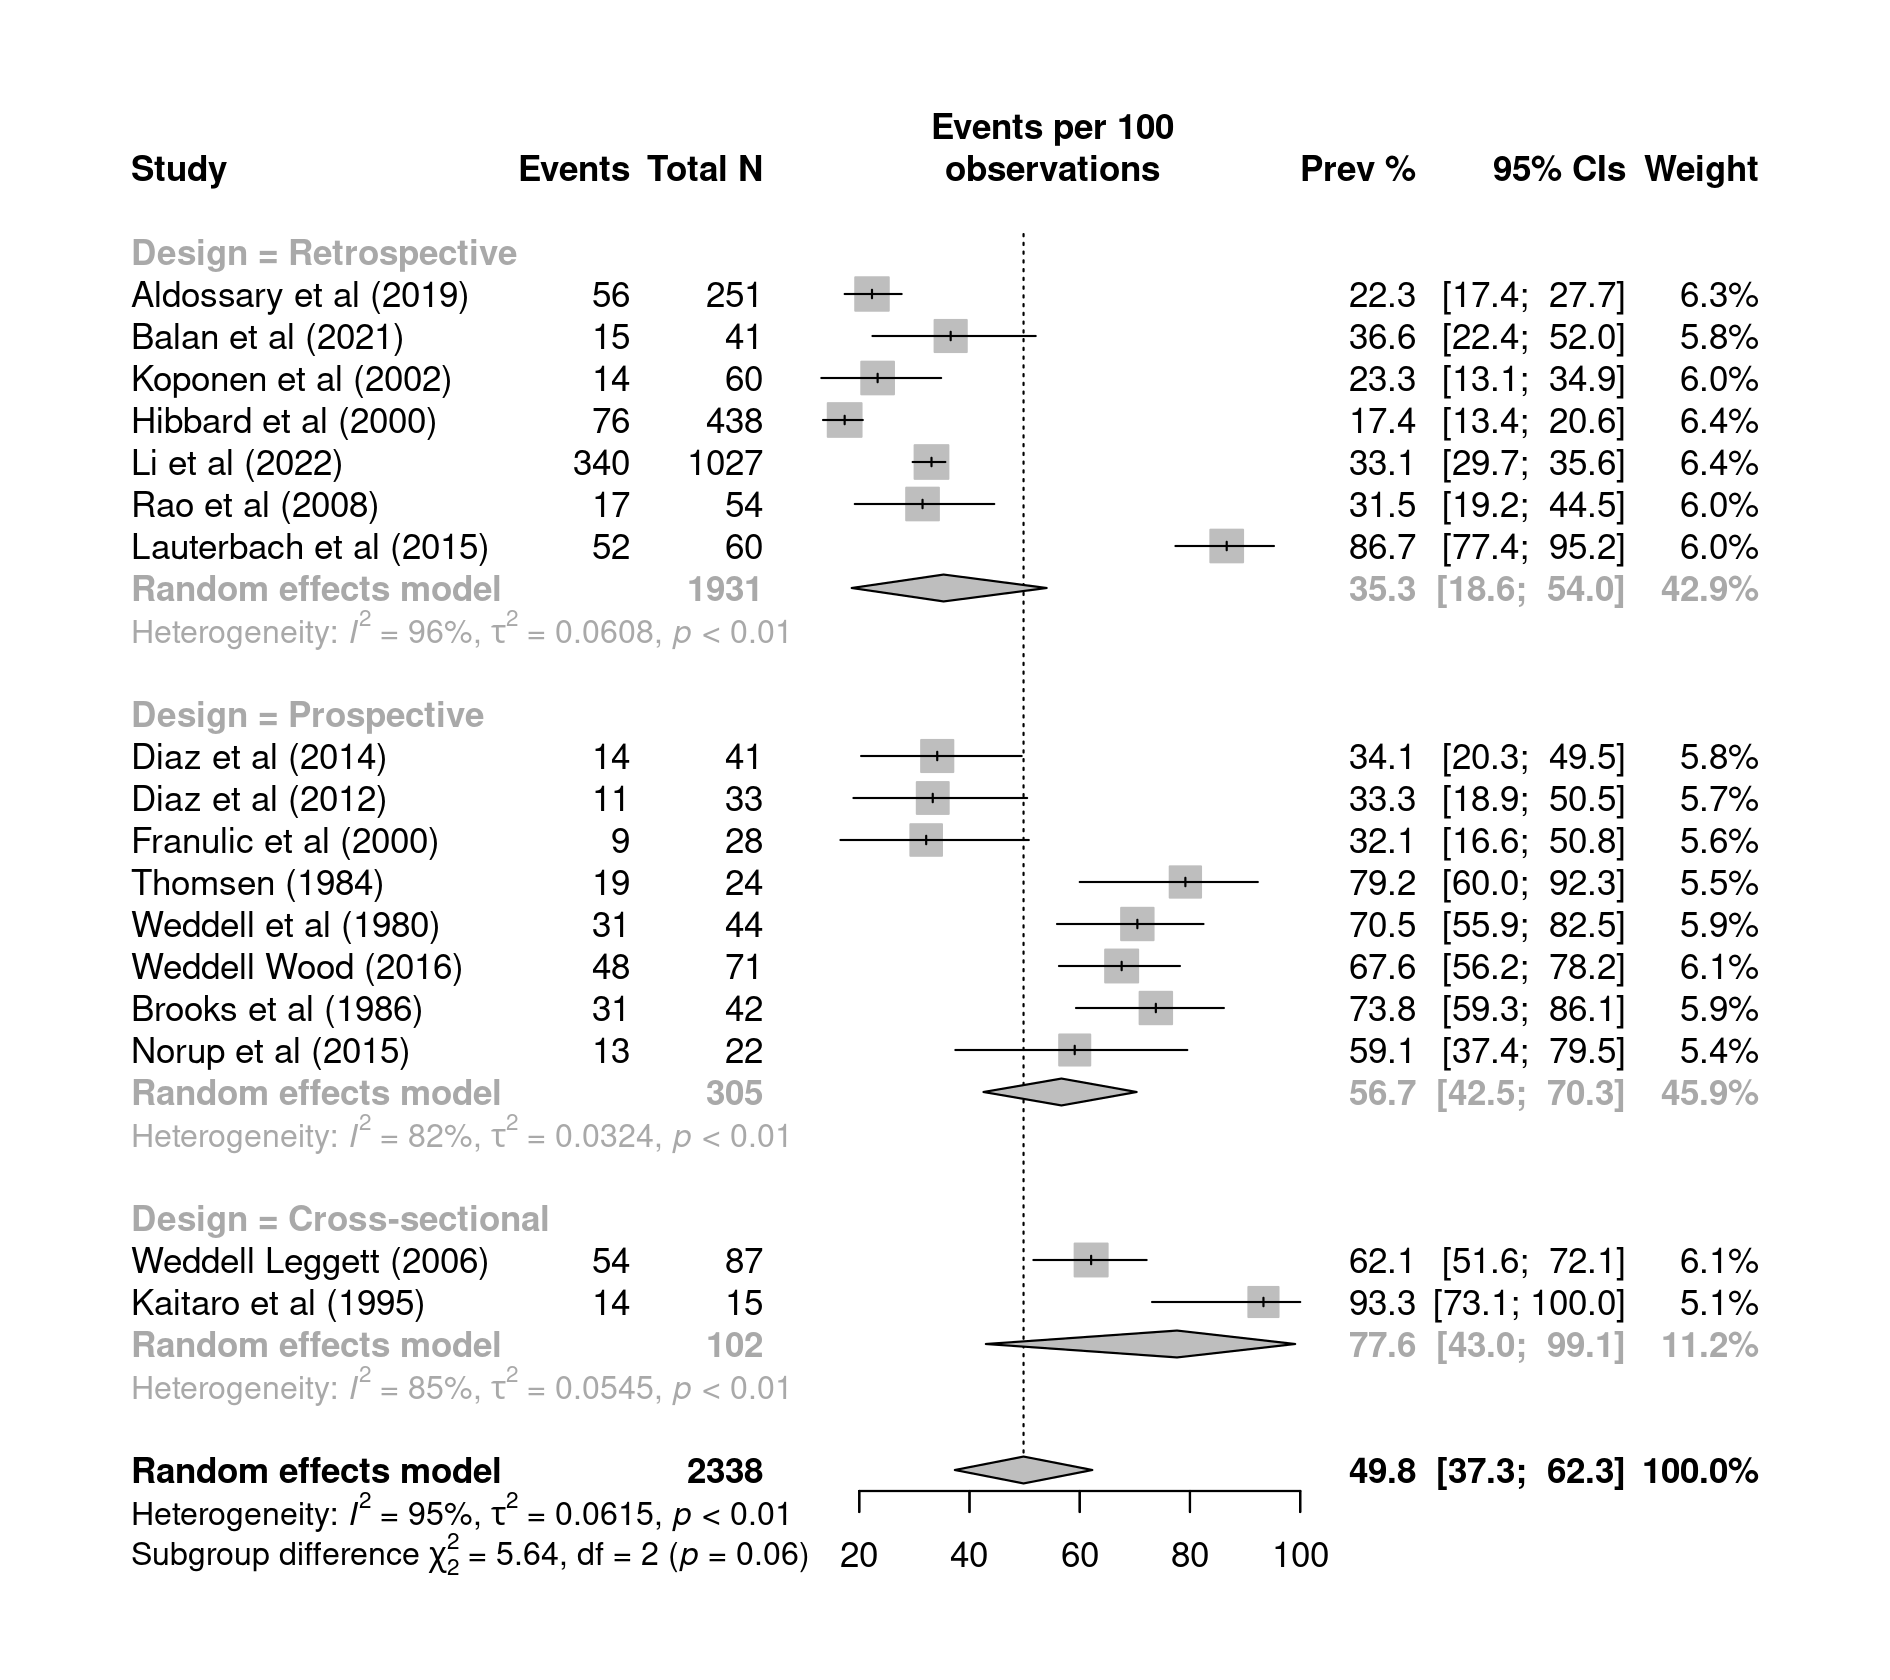

In [8]:
# Meta-analysis with study design subgroup
pc_design_meta <- metaprop(PersChange_N, TBI_N,
                           studlab = Authors,
                           subgroup = DesignCategory,
                           sm = "PFT",
                           method.tau = "PM",
                           method.ci = "NAsm",
                           data = pc_df)


# Set image size
options(repr.plot.width = 9, repr.plot.height = 8, repr.plot.res = 210)

# Forest plot
forest(pc_design_meta,
       subgroup.name = "Design",
       common = FALSE,
       common.subgroup = FALSE,
       test.effect.common = FALSE,
       test.overall.common = FALSE,
       test.effect.subgroup.common = FALSE,
       test.subgroup.common = FALSE,
       label.test.subgroup.random = "Subgroup difference ",
       leftlabs = c("Study", "Events", "Total N"),
       rightlabs = c("Prev %", "95% CIs", "Weight"),
       rightcols = c("effect", "ci", "w.random"),
       digits = 1,
       pscale = 100,
       xlim = c(10, 100),
       colgap.forest.left = unit(5, "mm"),
       colgap.forest.right = unit(0, "mm")
)

Validated or unvalidated outcome measure

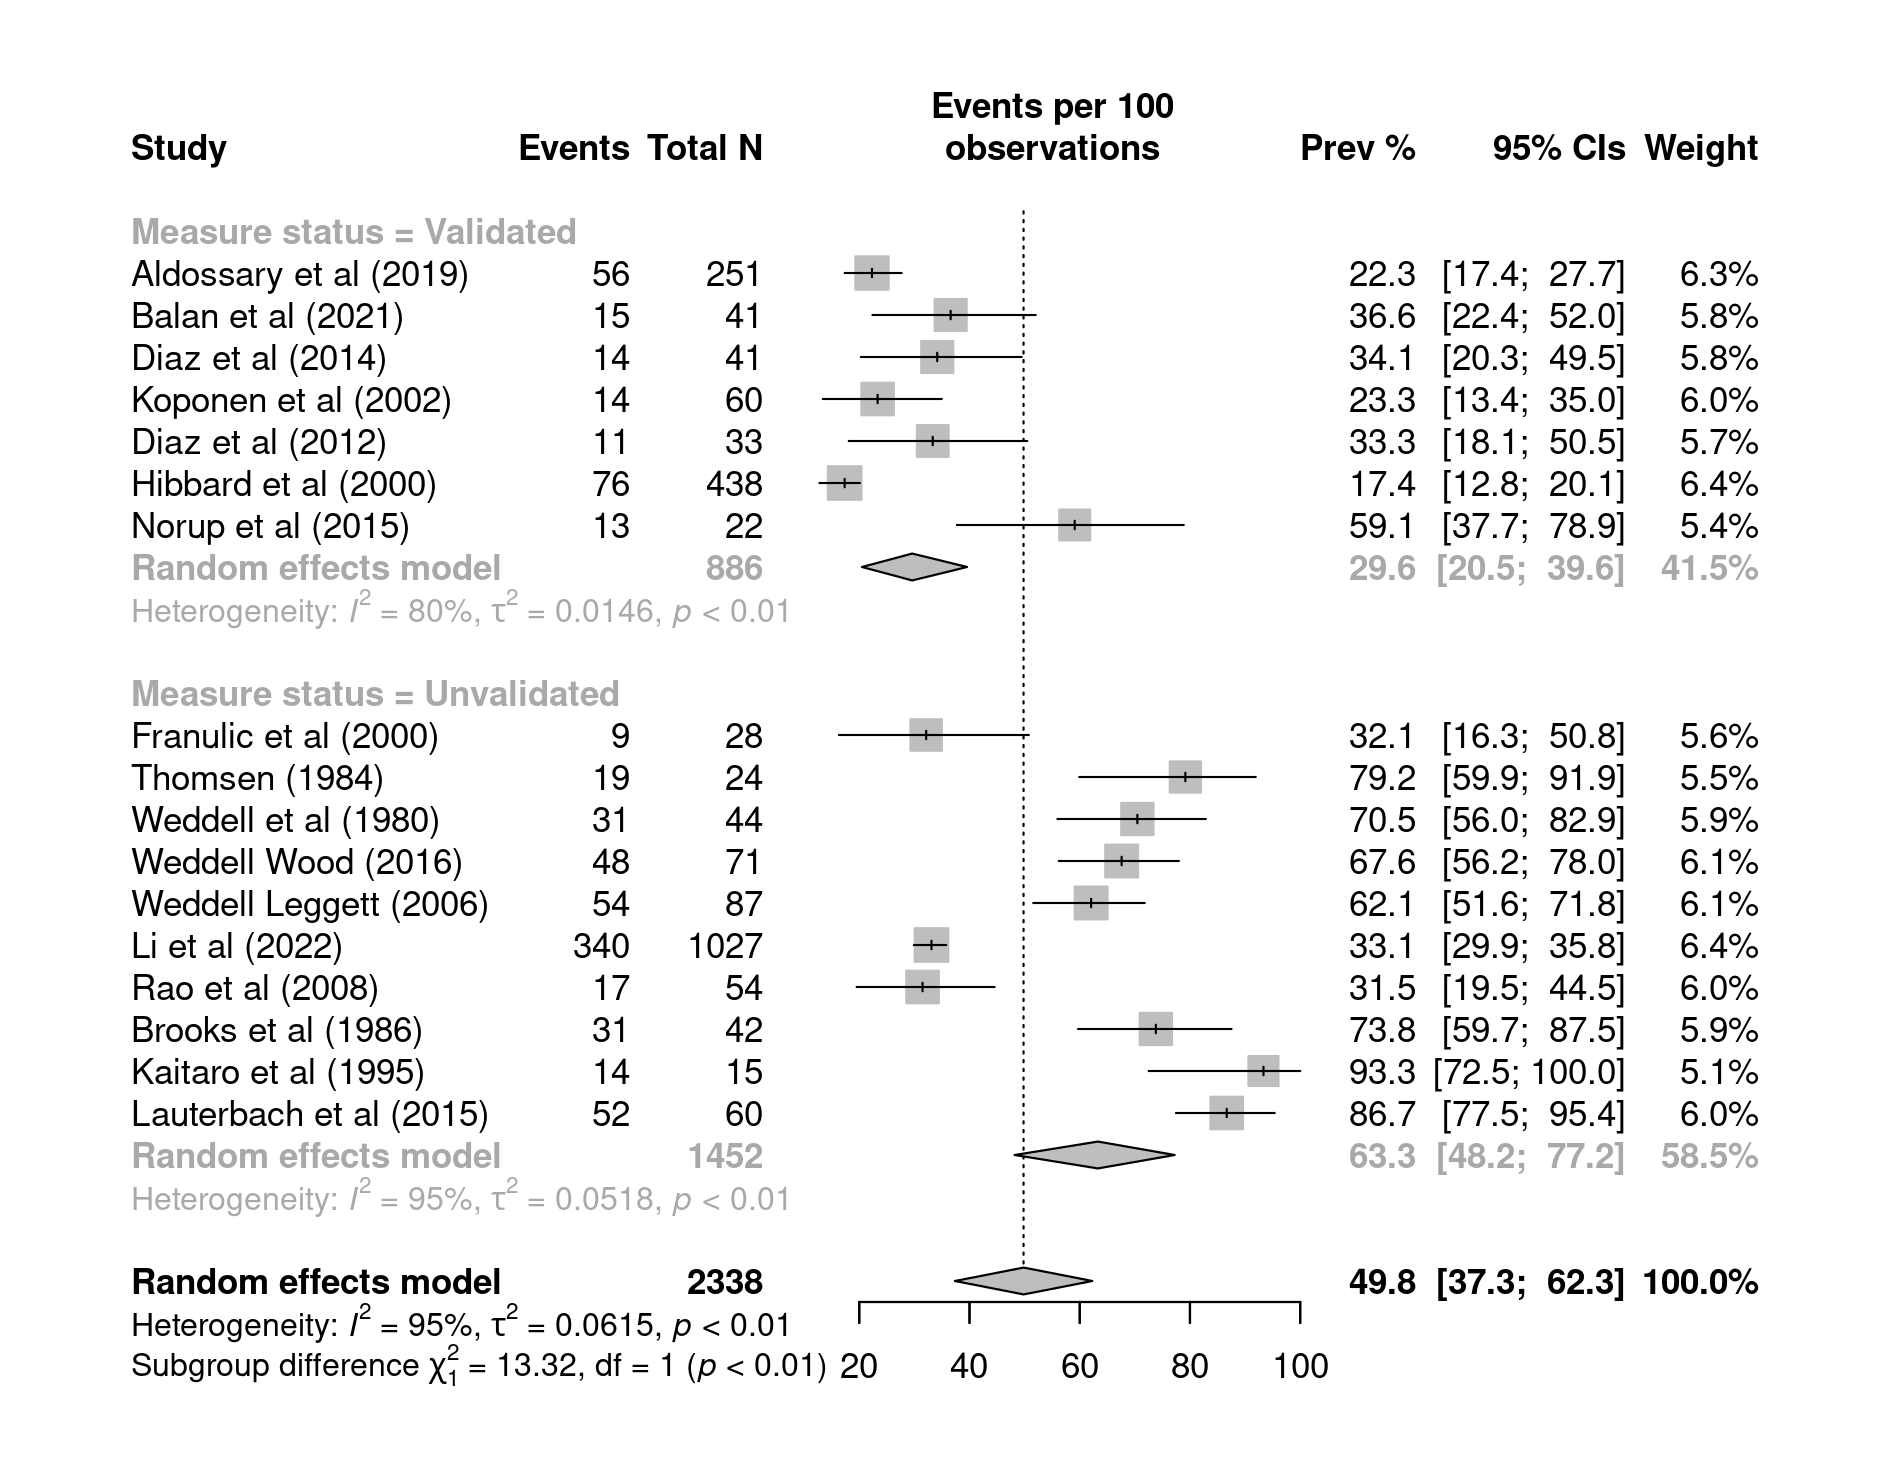

In [9]:
# Meta-analysis with measure status subgroup
pc_measurestatus_meta <- metaprop(PersChange_N, TBI_N,
                                  studlab = Authors,
                                  subgroup = OutcomeMeasureStatus,
                                  sm = "PFT",
                                  method.tau = "PM",
                                  method.ci = "NAsm",
                                  data = pc_df)


# Set image size
options(repr.plot.width = 9, repr.plot.height = 7, repr.plot.res = 210)

# Forest plot
forest(pc_measurestatus_meta,
       subgroup.name = "Measure status",
       common = FALSE,
       common.subgroup = FALSE,
       test.effect.common = FALSE,
       test.overall.common = FALSE,
       test.effect.subgroup.common = FALSE,
       test.subgroup.common = FALSE,
       label.test.subgroup.random = "Subgroup difference ",
       leftlabs = c("Study", "Events", "Total N"),
       rightlabs = c("Prev %", "95% CIs", "Weight"),
       rightcols = c("effect", "ci", "w.random"),
       digits = 1,
       pscale = 100,
       xlim = c(10, 100),
       colgap.forest.left = unit(5, "mm"),
       colgap.forest.right = unit(0, "mm")
)

Location (continent)

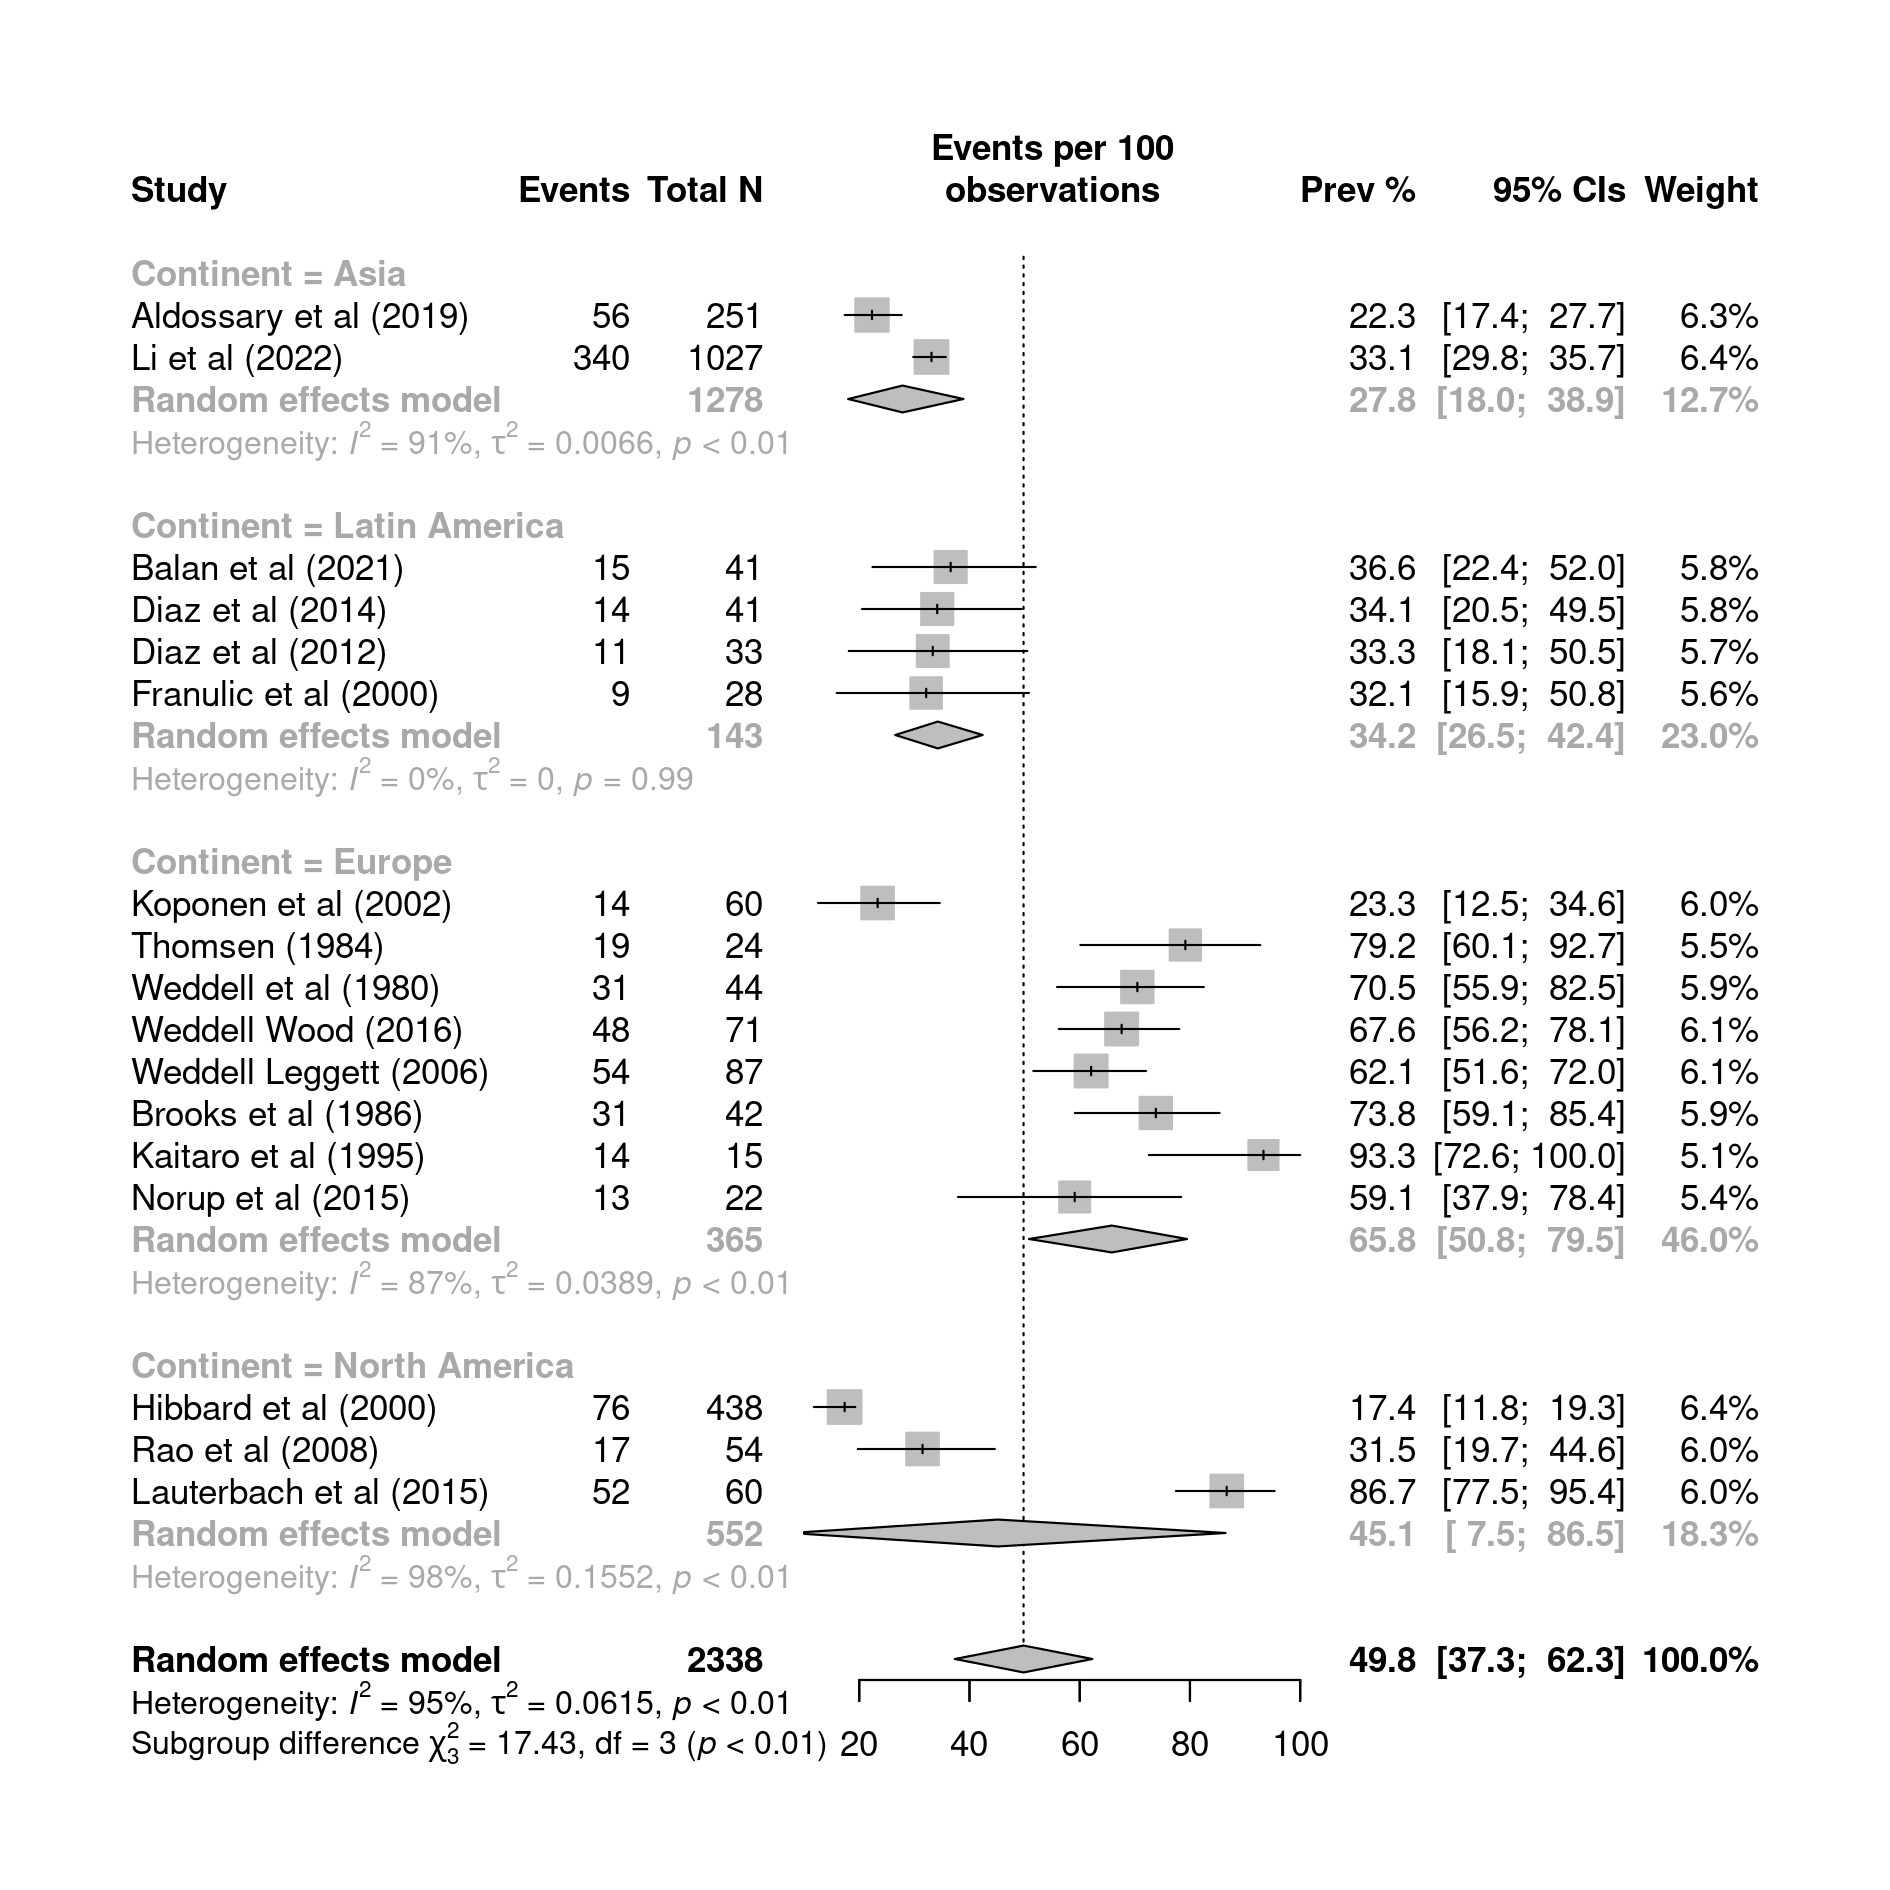

In [10]:
# Meta-analysis with location (continent) status subgroup
pc_continent_meta <- metaprop(PersChange_N, TBI_N,
                              studlab = Authors,
                              subgroup = Continent,
                              sm = "PFT",
                              method.tau = "PM",
                              method.ci = "NAsm",
                              data = pc_df)

# Set image size
options(repr.plot.width = 9, repr.plot.height = 9, repr.plot.res = 210)

# Forest plot
forest(pc_continent_meta,
       subgroup.name = "Continent",
       common = FALSE,
       common.subgroup = FALSE,
       test.effect.common = FALSE,
       test.overall.common = FALSE,
       test.effect.subgroup.common = FALSE,
       test.subgroup.common = FALSE,
       label.test.subgroup.random = "Subgroup difference ",
       leftlabs = c("Study", "Events", "Total N"),
       rightlabs = c("Prev %", "95% CIs", "Weight"),
       rightcols = c("effect", "ci", "w.random"),
       digits = 1,
       pscale = 100,
       xlim = c(10, 100),
       colgap.forest.left = unit(5, "mm"),
       colgap.forest.right = unit(0, "mm")
)

### Meta-regressions

Age

In [11]:
# Mean age
metareg(pc_meta, ~ mean_age)

Warning message:
“1 study with NAs omitted from model fitting.”



Mixed-Effects Model (k = 16; tau^2 estimator: PM)

tau^2 (estimated amount of residual heterogeneity):     0.0503 (SE = 0.0209)
tau (square root of estimated tau^2 value):             0.2242
I^2 (residual heterogeneity / unaccounted variability): 96.04%
H^2 (unaccounted variability / sampling variability):   25.26
R^2 (amount of heterogeneity accounted for):            3.56%

Test for Residual Heterogeneity:
QE(df = 14) = 276.2312, p-val < .0001

Test of Moderators (coefficient 2):
QM(df = 1) = 1.5109, p-val = 0.2190

Model Results:

          estimate      se     zval    pval    ci.lb   ci.ub      
intrcpt     1.0712  0.2623   4.0843  <.0001   0.5571  1.5852  *** 
mean_age   -0.0084  0.0069  -1.2292  0.2190  -0.0219  0.0050      

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Gender balance (proportion of males)

In [12]:
# Percent females
metareg(pc_meta, ~ PercentFemales)

Warning message:
“1 study with NAs omitted from model fitting.”



Mixed-Effects Model (k = 16; tau^2 estimator: PM)

tau^2 (estimated amount of residual heterogeneity):     0.0647 (SE = 0.0265)
tau (square root of estimated tau^2 value):             0.2544
I^2 (residual heterogeneity / unaccounted variability): 96.65%
H^2 (unaccounted variability / sampling variability):   29.87
R^2 (amount of heterogeneity accounted for):            0.00%

Test for Residual Heterogeneity:
QE(df = 14) = 296.4316, p-val < .0001

Test of Moderators (coefficient 2):
QM(df = 1) = 0.0009, p-val = 0.9761

Model Results:

                estimate      se     zval    pval    ci.lb   ci.ub      
intrcpt           0.7696  0.1273   6.0446  <.0001   0.5201  1.0192  *** 
PercentFemales   -0.0001  0.0032  -0.0300  0.9761  -0.0063  0.0061      

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Follow-up to measure

In [13]:
# Months follow up 
metareg(pc_meta, ~ FollowUpMonths)

Warning message:
“2 studies with NAs omitted from model fitting.”



Mixed-Effects Model (k = 15; tau^2 estimator: PM)

tau^2 (estimated amount of residual heterogeneity):     0.0584 (SE = 0.0249)
tau (square root of estimated tau^2 value):             0.2416
I^2 (residual heterogeneity / unaccounted variability): 96.34%
H^2 (unaccounted variability / sampling variability):   27.32
R^2 (amount of heterogeneity accounted for):            0.00%

Test for Residual Heterogeneity:
QE(df = 13) = 301.9277, p-val < .0001

Test of Moderators (coefficient 2):
QM(df = 1) = 0.0709, p-val = 0.7900

Model Results:

                estimate      se     zval    pval    ci.lb   ci.ub      
intrcpt           0.7804  0.0795   9.8214  <.0001   0.6247  0.9361  *** 
FollowUpMonths   -0.0002  0.0007  -0.2664  0.7900  -0.0016  0.0012      

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Proportion mTBI cases

In [14]:
# Percent of mTBI cases
metareg(pc_meta, ~ Percent_mTBI)

Warning message:
“3 studies with NAs omitted from model fitting.”



Mixed-Effects Model (k = 14; tau^2 estimator: PM)

tau^2 (estimated amount of residual heterogeneity):     0.0353 (SE = 0.0163)
tau (square root of estimated tau^2 value):             0.1879
I^2 (residual heterogeneity / unaccounted variability): 93.97%
H^2 (unaccounted variability / sampling variability):   16.58
R^2 (amount of heterogeneity accounted for):            26.12%

Test for Residual Heterogeneity:
QE(df = 12) = 201.6184, p-val < .0001

Test of Moderators (coefficient 2):
QM(df = 1) = 5.1657, p-val = 0.0230

Model Results:

              estimate      se     zval    pval    ci.lb    ci.ub      
intrcpt         0.8046  0.0655  12.2861  <.0001   0.6763   0.9330  *** 
Percent_mTBI   -0.0070  0.0031  -2.2728  0.0230  -0.0131  -0.0010    * 

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Proportion moderate TBI cases

In [15]:
# Percent of moderate TBI cases
metareg(pc_meta, ~ Percent_modTBI)

Warning message:
“3 studies with NAs omitted from model fitting.”



Mixed-Effects Model (k = 14; tau^2 estimator: PM)

tau^2 (estimated amount of residual heterogeneity):     0.0495 (SE = 0.0221)
tau (square root of estimated tau^2 value):             0.2225
I^2 (residual heterogeneity / unaccounted variability): 96.18%
H^2 (unaccounted variability / sampling variability):   26.20
R^2 (amount of heterogeneity accounted for):            0.00%

Test for Residual Heterogeneity:
QE(df = 12) = 254.0661, p-val < .0001

Test of Moderators (coefficient 2):
QM(df = 1) = 0.5832, p-val = 0.4451

Model Results:

                estimate      se    zval    pval    ci.lb   ci.ub      
intrcpt           0.6814  0.0796  8.5575  <.0001   0.5253  0.8375  *** 
Percent_modTBI    0.0034  0.0044  0.7637  0.4451  -0.0053  0.0120      

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Proportion severe cases

In [16]:
# Percent of severe TBI cases
metareg(pc_meta, ~ Percent_sevTBI)

Warning message:
“3 studies with NAs omitted from model fitting.”



Mixed-Effects Model (k = 14; tau^2 estimator: PM)

tau^2 (estimated amount of residual heterogeneity):     0.0487 (SE = 0.0218)
tau (square root of estimated tau^2 value):             0.2207
I^2 (residual heterogeneity / unaccounted variability): 95.75%
H^2 (unaccounted variability / sampling variability):   23.52
R^2 (amount of heterogeneity accounted for):            0.00%

Test for Residual Heterogeneity:
QE(df = 12) = 230.3874, p-val < .0001

Test of Moderators (coefficient 2):
QM(df = 1) = 0.7788, p-val = 0.3775

Model Results:

                estimate      se    zval    pval    ci.lb   ci.ub     
intrcpt           0.5586  0.1923  2.9040  0.0037   0.1816  0.9356  ** 
Percent_sevTBI    0.0021  0.0024  0.8825  0.3775  -0.0026  0.0068     

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Year of publication

In [17]:
# Year of publication
metareg(pc_meta, ~ Year)


Mixed-Effects Model (k = 17; tau^2 estimator: PM)

tau^2 (estimated amount of residual heterogeneity):     0.0545 (SE = 0.0219)
tau (square root of estimated tau^2 value):             0.2335
I^2 (residual heterogeneity / unaccounted variability): 95.15%
H^2 (unaccounted variability / sampling variability):   20.63
R^2 (amount of heterogeneity accounted for):            11.31%

Test for Residual Heterogeneity:
QE(df = 15) = 322.3150, p-val < .0001

Test of Moderators (coefficient 2):
QM(df = 1) = 2.8281, p-val = 0.0926

Model Results:

         estimate      se     zval    pval    ci.lb    ci.ub    
intrcpt   16.5096  9.3520   1.7654  0.0775  -1.8199  34.8392  . 
Year      -0.0078  0.0047  -1.6817  0.0926  -0.0170   0.0013  . 

---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Relationship with study risk of bias rating

In [18]:
#
#
# TBC
#
#

### Robustness and sensitivity analyses

#### Publication bias

Funnel plot

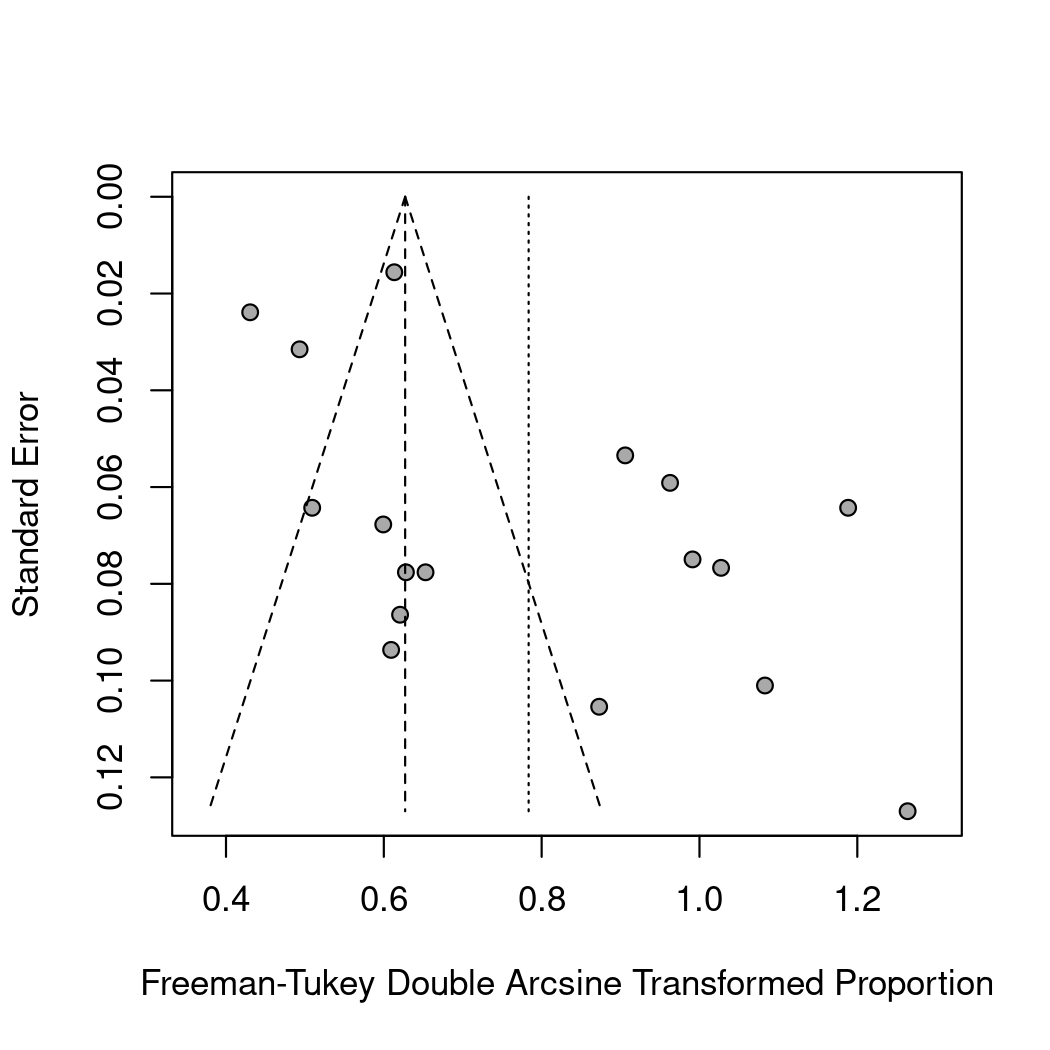

In [19]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 210)
funnel(pc_meta)

Egger's test

In [20]:
metabias(pc_meta, method.bias = "linreg")

Linear regression test of funnel plot asymmetry

Test result: t = 2.80, df = 15, p-value = 0.0134
Bias estimate: 4.3202 (SE = 1.5419)

Details:
- multiplicative residual heterogeneity variance (tau^2 = 14.3380)
- predictor: standard error
- weight:    inverse variance
- reference: Egger et al. (1997), BMJ

Impute missing cases using trim and fill (adjust estimate for publication bias)

In [21]:
trimfill(pc_meta)

Number of studies: k = 23 (with 6 added studies)

                     proportion           95%-CI
Random effects model     0.3145 [0.1718; 0.4766]

Quantifying heterogeneity:
 tau^2 = 0.1517 [0.0874; 0.3123]; tau = 0.3895 [0.2957; 0.5589]
 I^2 = 96.4% [95.5%; 97.1%]; H = 5.27 [4.70; 5.91]

Test of heterogeneity:
      Q d.f.  p-value
 610.89   22 < 0.0001

Details on meta-analytical method:
- Inverse variance method
- Paule-Mandel estimator for tau^2
- Q-Profile method for confidence interval of tau^2 and tau
- Trim-and-fill method to adjust for funnel plot asymmetry (L-estimator)
- Freeman-Tukey double arcsine transformation

Outliers

In [22]:
dmetar_fo_output <- dmetar::find.outliers(pc_meta)

# Print outliers from random effects model
dmetar_fo_output$out.study.random

# Store recalculated meta minus outliers (dmetar automatically recalculates this and stores it in dmetar_fo_output$m.random
pc_meta_minus_outliers <- dmetar_fo_output$m.random

[1] "Aldossary et al (2019)"  "Koponen et al (2002)"   
[3] "Hibbard et al (2000)"    "Li et al (2022)"        
[5] "Kaitaro et al (1995)"    "Lauterbach et al (2015)"

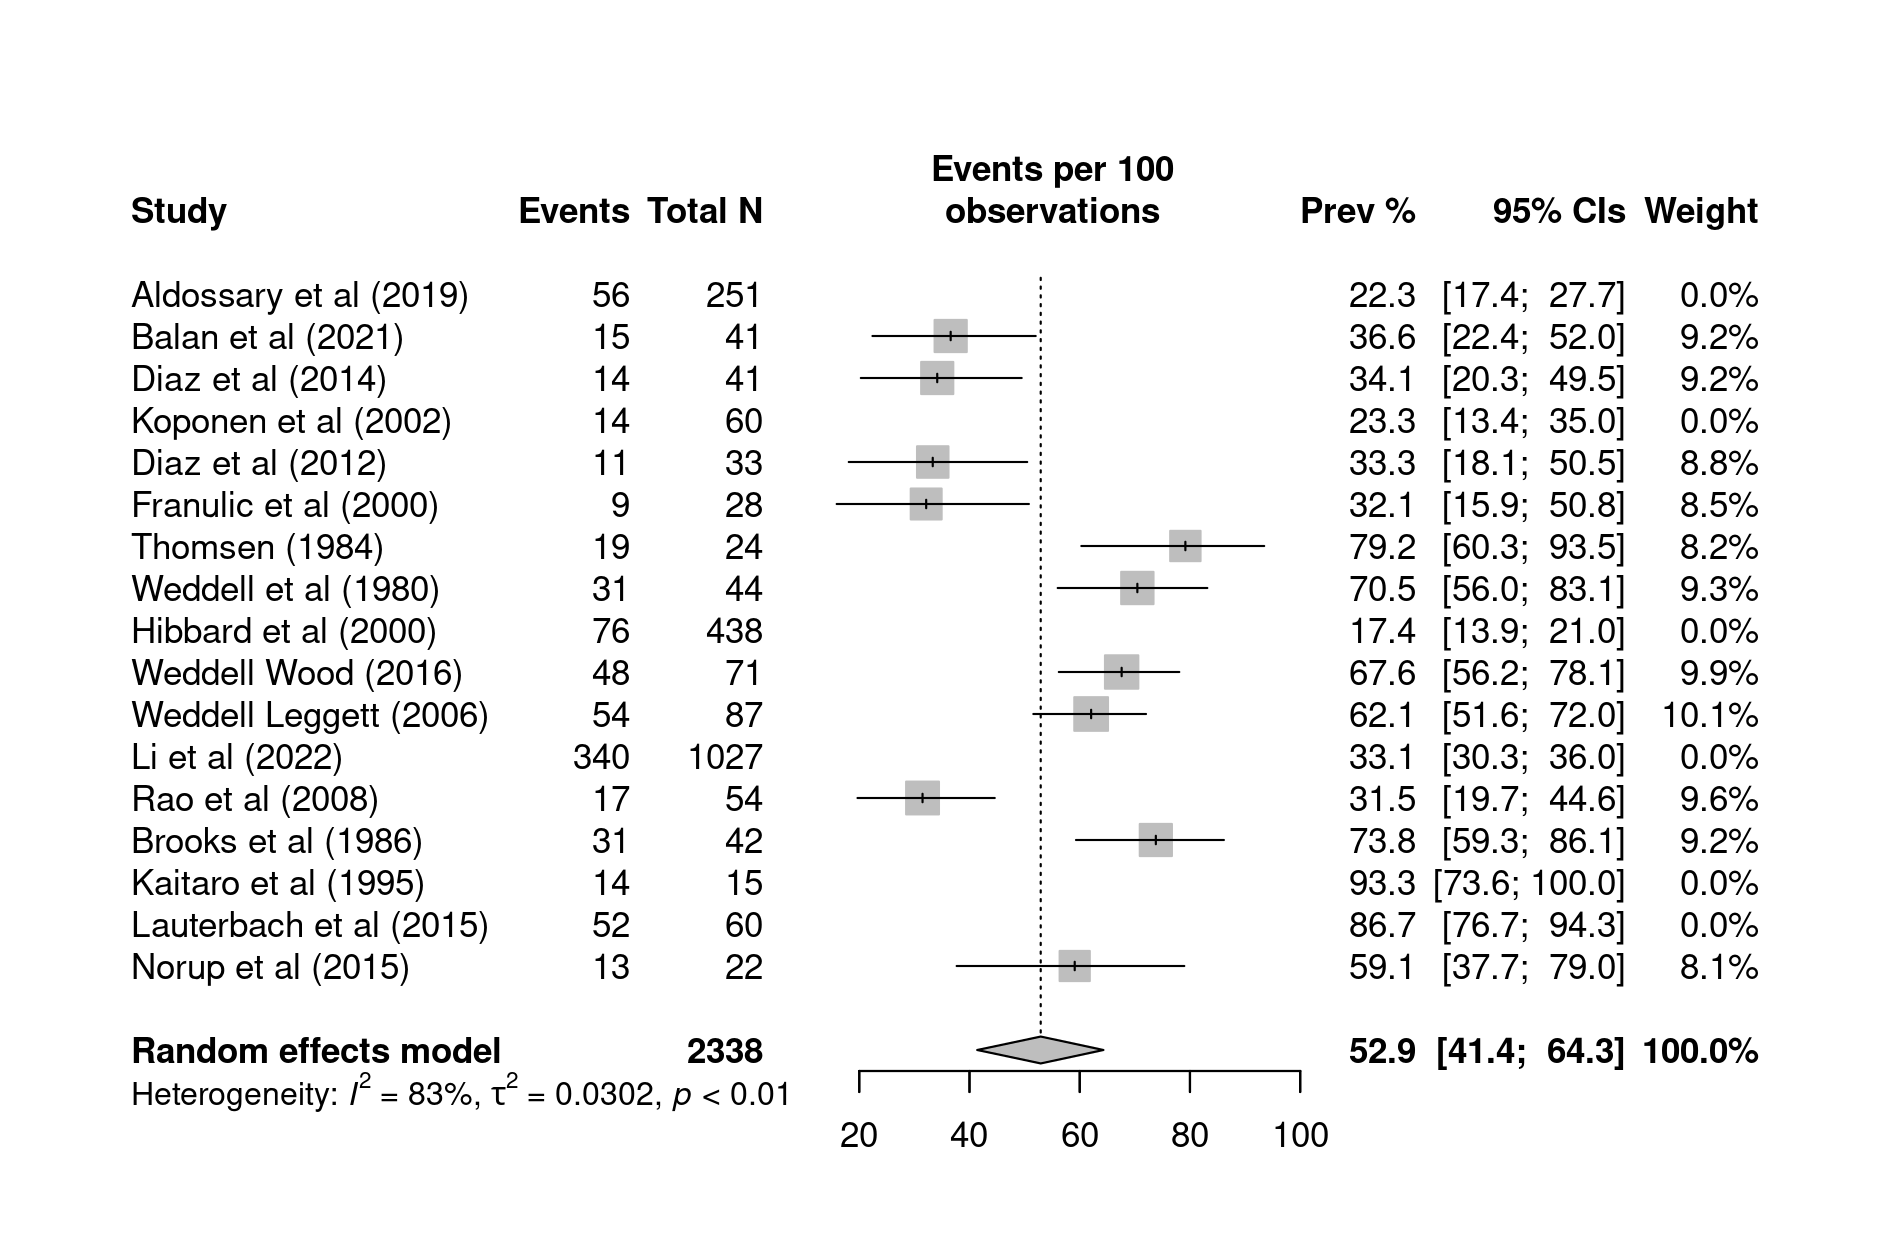

In [23]:
# Set image size
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 210)

# Show recalculated meta with 
forest(pc_meta_minus_outliers,
       common = FALSE,
       test.effect.common = FALSE,
       test.overall.common = FALSE,
       leftlabs = c("Study", "Events", "Total N"),
       rightlabs = c("Prev %", "95% CIs", "Weight"),
       rightcols = c("effect", "ci", "w.random"),
       digits = 1,
       pscale = 100,
       xlim = c(10, 100),
       colgap.forest.left = unit(5, "mm"),
       colgap.forest.right = unit(0, "mm")
)

Influence diagnostics

[===========================================================================] DONE 


Leave-One-Out Analysis (Sorted by I2) 
 ----------------------------------- 
                                 Effect  LLCI  ULCI    I2
Omitting Hibbard et al (2000)     0.807 0.685 0.929 0.939
Omitting Lauterbach et al (2015)  0.757 0.637 0.876 0.940
Omitting Weddell Wood (2016)      0.772 0.643 0.901 0.949
Omitting Weddell Leggett (2006)   0.776 0.646 0.906 0.950
Omitting Brooks et al (1986)      0.768 0.641 0.896 0.950
Omitting Kaitaro et al (1995)     0.757 0.640 0.874 0.950
Omitting Aldossary et al (2019)   0.803 0.678 0.928 0.951
Omitting Thomsen (1984)           0.766 0.641 0.891 0.951
Omitting Weddell et al (1980)     0.771 0.643 0.899 0.951
Omitting Norup et al (2015)       0.779 0.649 0.909 0.953
Omitting Balan et al (2021)       0.792 0.662 0.922 0.954
Omitting Diaz et al (2014)        0.793 0.664 0.923 0.954
Omitting Koponen et al (2002)     0.801 0.675 0.927 0.954
Omitting Diaz et al (2012)        0.794 0.664 0.923 0.954
Omitting Franulic et al (2000)    0.794 0.665 0.923 0

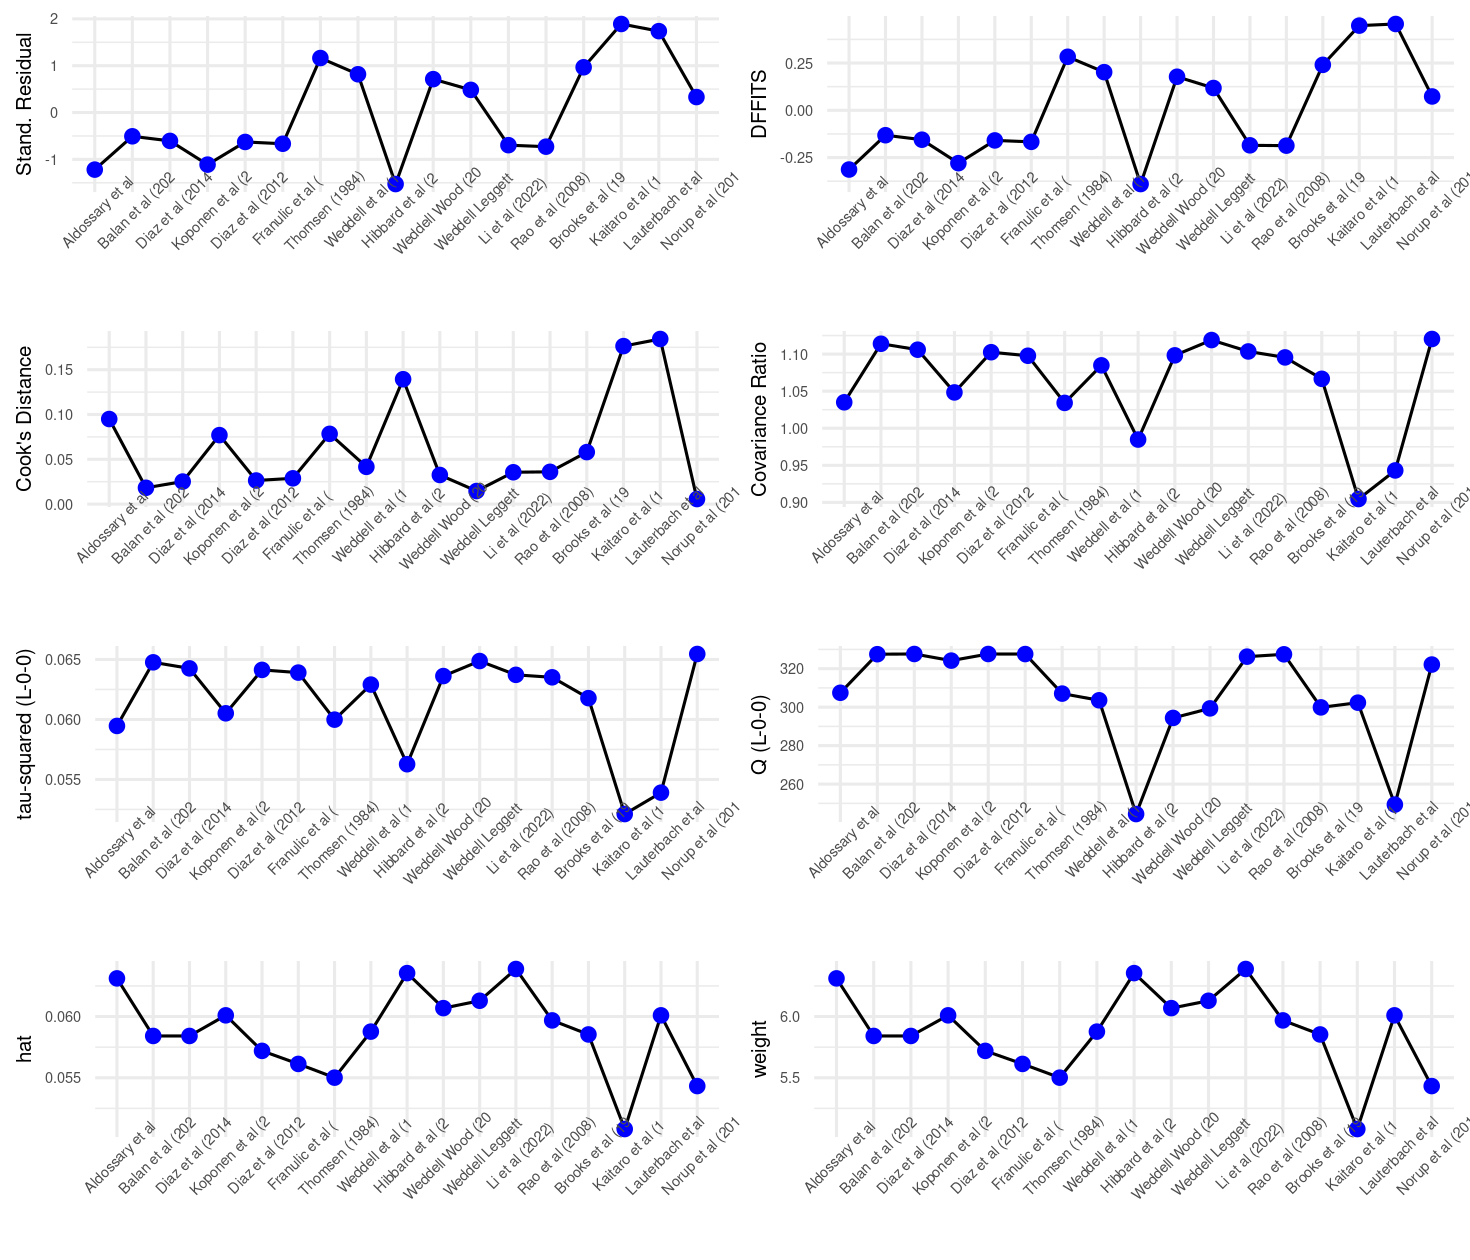

In [24]:
pc_meta_inf_diagnostics <- dmetar::InfluenceAnalysis(pc_meta, random = TRUE)
pc_meta_inf_diagnostics

options(repr.plot.width = 7, repr.plot.height = 6, repr.plot.res = 210)
plot(pc_meta_inf_diagnostics, "influence")

Leave one out sensitivity diagnostics

In [25]:
# Leave1Out sensitivity analysis
metainf(pc_meta, pooled = "random")

Influential analysis (random effects model)

                                 proportion           95%-CI p-value   tau^2
Omitting Aldossary et al (2019)      0.5179 [0.3905; 0.6442]          0.0595
Omitting Balan et al (2021)          0.5067 [0.3751; 0.6379]          0.0648
Omitting Diaz et al (2014)           0.5083 [0.3770; 0.6389]          0.0643
Omitting Koponen et al (2002)        0.5159 [0.3878; 0.6430]          0.0605
Omitting Diaz et al (2012)           0.5085 [0.3775; 0.6389]          0.0641
Omitting Franulic et al (2000)       0.5090 [0.3783; 0.6391]          0.0639
Omitting Thomsen (1984)              0.4801 [0.3542; 0.6072]          0.0600
Omitting Weddell et al (1980)        0.4850 [0.3558; 0.6152]          0.0629
Omitting Hibbard et al (2000)        0.5221 [0.3976; 0.6452]          0.0563
Omitting Weddell Wood (2016)         0.4865 [0.3564; 0.6175]          0.0636
Omitting Weddell Leggett (2006)      0.4903 [0.3588; 0.6224]          0.0649
Omitting Li et al (2022)       

### Analysis platform details and software versions

In [26]:
version

               _                                          
platform       x86_64-pc-linux-gnu                        
arch           x86_64                                     
os             linux-gnu                                  
system         x86_64, linux-gnu                          
status         Patched                                    
major          4                                          
minor          2.2                                        
year           2022                                       
month          11                                         
day            10                                         
svn rev        83330                                      
language       R                                          
version.string R version 4.2.2 Patched (2022-11-10 r83330)
nickname       Innocent and Trusting                      

In [27]:
packageVersion("dplyr")

[1] ‘1.1.4’

In [28]:
packageVersion("readxl")

[1] ‘1.4.3’

In [29]:
packageVersion("meta")

[1] ‘7.0.0’

In [30]:
packageVersion("dmetar")

[1] ‘0.1.0’

In [31]:
packageVersion("grid")

[1] ‘4.2.2’